# QAOA for Maximum Cut
## Part V: Noise Analysis

**Physics 565/656 · Spring 2026 · Sehong Park**

Real quantum hardware is subject to gate errors, decoherence, and readout noise.
This notebook studies how depolarizing noise on CX gates degrades QAOA performance,
and identifies the regime where deeper circuits ($p=3$) become counterproductive.

**Noise model:** After each CX gate, apply the 2-qubit depolarizing channel:
$$\mathcal{E}(\rho) = (1-p_{cx})\rho
+ \frac{p_{cx}}{15}\sum_{P \in \{I,X,Y,Z\}^{\otimes 2}\setminus\{I^{\otimes 2}\}}P\rho P^\dagger$$

Single-qubit gate errors: $p_{1q} = p_{cx}/10$, reflecting the typical asymmetry in superconducting architectures.

**Parameters:** Loaded from `optimal_params.json` produced by Notebook 05 (warm-start optimisation).
This avoids hardcoded magic numbers and ensures the noise analysis uses the same parameters as the noiseless experiments.

---
## 1. Setup

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from scipy.optimize import minimize
import json, warnings
warnings.filterwarnings('ignore')

MASTER_SEED = 42
np.random.seed(MASTER_SEED)
n = 10

# ── Graphs (same as Notebook 05) ──────────────────────────────────
G1 = nx.cycle_graph(n); e1 = list(G1.edges())

G2 = nx.cycle_graph(n)
non_edges = [(i,j) for i in range(n) for j in range(i+2,n)
             if abs(i-j)>1 and not(i==0 and j==n-1)]
chords = [non_edges[c] for c in
          np.random.default_rng(0).choice(len(non_edges),3,replace=False)]
for c in chords: G2.add_edge(*c)
e2 = list(G2.edges())

G3 = nx.random_regular_graph(3, n, seed=7); e3 = list(G3.edges())

GRAPHS = [
    (r'$C_{10}$',            e1, 10),
    (r'$C_{10}$ + 3 chords', e2, 13),
    (r'3-regular ($n=10$)',   e3, 13),
]
GRAPH_KEYS = ['C10', 'C10_chords', '3reg']

# ── Load optimal parameters from Notebook 05 ─────────────────────
try:
    with open('optimal_params.json', 'r') as f:
        OPTIMAL_PARAMS = json.load(f)
    # JSON keys are strings; convert p keys to int
    OPTIMAL_PARAMS = {k: {int(p): v for p,v in d.items()}
                      for k, d in OPTIMAL_PARAMS.items()}
    print('Loaded optimal_params.json from Notebook 05.')
except FileNotFoundError:
    print('WARNING: optimal_params.json not found.')
    print('Run Notebook 05 first to generate parameters.')
    print('Falling back to approximate values for demonstration.')
    # Fallback: approximate values (not for publication)
    OPTIMAL_PARAMS = {
        'C10':        {1: [0.7854, 1.9635],
                       2: [0.656,  1.243,  2.1922, 0.3279],
                       3: [0.5917, 1.1556, 1.3642, 2.253,  2.1487, 1.8668]},
        'C10_chords': {1: [0.663,  1.9635],
                       2: [0.5063, 0.9236, 2.1449, 0.324],
                       3: [0.4855, 0.8018, 0.9462, 0.6465, 2.1271, 1.9066]},
        '3reg':       {1: [2.5534, 1.9359],
                       2: [0.5083, 0.9205, 2.0785, 1.8523],
                       3: [0.7573, -0.3054, 1.3101, 1.096, 0.9487, 0.2493]},
    }

print(f'Graphs: {[g[0] for g in GRAPHS]}')
print(f'CX count per layer: {[2*len(g[1]) for g in GRAPHS]}')
for key in GRAPH_KEYS:
    print(f'  {key}: p=1 params = {OPTIMAL_PARAMS[key][1]}')

Loaded optimal_params.json from Notebook 05.
Graphs: ['$C_{10}$', '$C_{10}$ + 3 chords', '3-regular ($n=10$)']
CX count per layer: [20, 26, 30]
  C10: p=1 params = [0.7853929797057941, 0.3926974966532]
  C10_chords: p=1 params = [0.6630388603082829, 1.9635056658892753]
  3reg: p=1 params = [0.5882207743672121, 1.9358731414391392]


---
## 2. Noise Model and Circuit

The cost unitary $e^{-i\gamma H_C}$ decomposes per edge $(i,j)$ as:
$$\text{CX}_{ij} \cdot RZ(-\gamma, j) \cdot \text{CX}_{ij}$$

Each layer uses $2|E|$ CX gates. At depth $p$: total CX $= 2p|E|$, and noise accumulates multiplicatively.

**Key tradeoff:** deeper circuits ($p=3$) have $3\times$ more CX gates than $p=1$.
At high $p_{cx}$, error accumulation outweighs the expressibility gain → crossover point.

In [2]:
def build_circuit(edges, n, p, gamma, beta):
    """
    QAOA circuit for MaxCut.
    Cost: CX - RZ(-γ) - CX per edge  [implements e^{iγ Z_iZ_j/2}]
    Mixer: RX(2β) per qubit           [implements e^{-iβ X}]
    """
    qc = QuantumCircuit(n)
    qc.h(range(n))
    for k in range(p):
        for i,j in edges:
            qc.cx(i,j); qc.rz(-gamma[k],j); qc.cx(i,j)
        for q in range(n):
            qc.rx(2*beta[k], q)
    qc.measure_all()
    return qc

def build_noise_model(p_cx):
    nm = NoiseModel()
    if p_cx > 0:
        nm.add_all_qubit_quantum_error(depolarizing_error(p_cx, 2), ['cx'])
        nm.add_all_qubit_quantum_error(depolarizing_error(p_cx/10, 1), ['h','rx','rz'])
    return nm

def eval_noisy(edges, n, p, gamma, beta, p_cx, shots=4096, seed=42):
    qc = build_circuit(edges, n, p, gamma, beta)
    sim = AerSimulator(noise_model=build_noise_model(p_cx), seed_simulator=seed)
    counts = sim.run(transpile(qc, sim, seed_transpiler=42), shots=shots).result().get_counts()
    total = sum(counts.values()); E = 0.0
    for bs, cnt in counts.items():
        bits = [int(b) for b in reversed(bs)]
        E += sum(1 for i,j in edges if bits[i]!=bits[j]) * cnt / total
    return E

# Circuit stats
print('Circuit resource counts:')
for name, edges, opt in GRAPHS:
    for p in [1,2,3]:
        qc = build_circuit(edges, n, p, [0.5]*p, [0.3]*p)
        cx = qc.count_ops().get('cx', 0)
        print(f'  {name} p={p}: CX={cx}, fidelity model={(1-0.01)**cx:.3f} at p_cx=1%')

Circuit resource counts:
  $C_{10}$ p=1: CX=20, fidelity model=0.818 at p_cx=1%
  $C_{10}$ p=2: CX=40, fidelity model=0.669 at p_cx=1%
  $C_{10}$ p=3: CX=60, fidelity model=0.547 at p_cx=1%
  $C_{10}$ + 3 chords p=1: CX=26, fidelity model=0.770 at p_cx=1%
  $C_{10}$ + 3 chords p=2: CX=52, fidelity model=0.593 at p_cx=1%
  $C_{10}$ + 3 chords p=3: CX=78, fidelity model=0.457 at p_cx=1%
  3-regular ($n=10$) p=1: CX=30, fidelity model=0.740 at p_cx=1%
  3-regular ($n=10$) p=2: CX=60, fidelity model=0.547 at p_cx=1%
  3-regular ($n=10$) p=3: CX=90, fidelity model=0.405 at p_cx=1%


---
## 3. Noise Sweep: $p_{cx} \in [0, 0.025]$

For each noise level, QAOA is evaluated using the **noiseless optimal parameters** from Notebook 05.
This design choice isolates the effect of noise on circuit fidelity,
separate from the effect of noise on parameter optimisation.

A complementary experiment (re-optimising parameters under noise) is discussed in Section 6.

In [3]:
PCX_VALS = [0.000, 0.002, 0.004, 0.006, 0.008, 0.010, 0.015, 0.020, 0.025]
SHOTS    = 4096
P_VALS   = [1, 2, 3]

noise_results = {key: {p: [] for p in P_VALS} for key in GRAPH_KEYS}

for (name, edges, opt), gkey in zip(GRAPHS, GRAPH_KEYS):
    print(f'\n{name}')
    for p_cx in PCX_VALS:
        for p in P_VALS:
            params = OPTIMAL_PARAMS[gkey][p]
            gamma  = params[:p]; beta = params[p:]
            ratio  = eval_noisy(edges, n, p, gamma, beta, p_cx, SHOTS) / opt
            noise_results[gkey][p].append(ratio)
        print(f'  p_cx={p_cx:.3f}: '
              f'p1={noise_results[gkey][1][-1]:.4f} '
              f'p2={noise_results[gkey][2][-1]:.4f} '
              f'p3={noise_results[gkey][3][-1]:.4f}')

print('\nSweep complete.')


$C_{10}$
  p_cx=0.000: p1=0.7502 p2=0.8335 p3=0.8753
  p_cx=0.002: p1=0.7465 p2=0.8249 p3=0.8634
  p_cx=0.004: p1=0.7446 p2=0.8191 p3=0.8500
  p_cx=0.006: p1=0.7416 p2=0.8100 p3=0.8393
  p_cx=0.008: p1=0.7390 p2=0.8046 p3=0.8279
  p_cx=0.010: p1=0.7374 p2=0.7966 p3=0.8161
  p_cx=0.015: p1=0.7284 p2=0.7805 p3=0.7861
  p_cx=0.020: p1=0.7243 p2=0.7650 p3=0.7633
  p_cx=0.025: p1=0.7167 p2=0.7515 p3=0.7419

$C_{10}$ + 3 chords
  p_cx=0.000: p1=0.7067 p2=0.7920 p3=0.8723
  p_cx=0.002: p1=0.7046 p2=0.7832 p3=0.8512
  p_cx=0.004: p1=0.7019 p2=0.7727 p3=0.8312
  p_cx=0.006: p1=0.7000 p2=0.7617 p3=0.8112
  p_cx=0.008: p1=0.6959 p2=0.7551 p3=0.7951
  p_cx=0.010: p1=0.6924 p2=0.7476 p3=0.7775
  p_cx=0.015: p1=0.6865 p2=0.7291 p3=0.7428
  p_cx=0.020: p1=0.6804 p2=0.7107 p3=0.7116
  p_cx=0.025: p1=0.6702 p2=0.6939 p3=0.6844

3-regular ($n=10$)
  p_cx=0.000: p1=0.7766 p2=0.8500 p3=0.9034
  p_cx=0.002: p1=0.7725 p2=0.8405 p3=0.8831
  p_cx=0.004: p1=0.7699 p2=0.8297 p3=0.8659
  p_cx=0.006: p1=0.7656 p

---
## 4. Results: Ratio Degradation

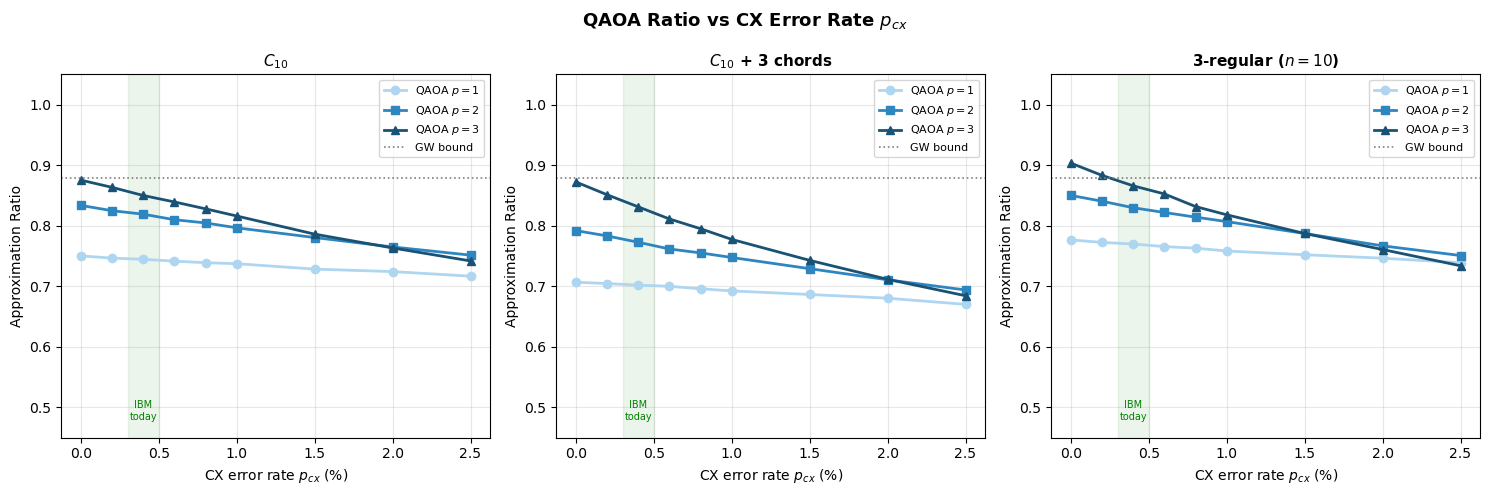

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pcx_pct = [v*100 for v in PCX_VALS]
colors  = {1:'#AED6F1', 2:'#2E86C1', 3:'#1A5276'}
markers = {1:'o', 2:'s', 3:'^'}

for ax, (name, edges, opt), gkey in zip(axes, GRAPHS, GRAPH_KEYS):
    for p in P_VALS:
        ax.plot(pcx_pct, noise_results[gkey][p], f'{markers[p]}-',
                color=colors[p], lw=2, ms=6, label=f'QAOA $p={p}$')
    ax.axhline(0.8786, color='gray', ls=':', lw=1.2, label='GW bound')
    ax.axvspan(0.3, 0.5, alpha=0.08, color='green')
    ax.text(0.4, 0.48, 'IBM\ntoday', fontsize=7, ha='center', color='green')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel(r'CX error rate $p_{cx}$ (%)', fontsize=10)
    ax.set_ylabel('Approximation Ratio', fontsize=10)
    ax.set_ylim(0.45, 1.05)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(r'QAOA Ratio vs CX Error Rate $p_{cx}$', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 5. Crossover Analysis

The **crossover point** $p_{cx}^*$ is where a shallower circuit first outperforms a deeper one.
This determines the optimal QAOA depth for a given hardware noise level.

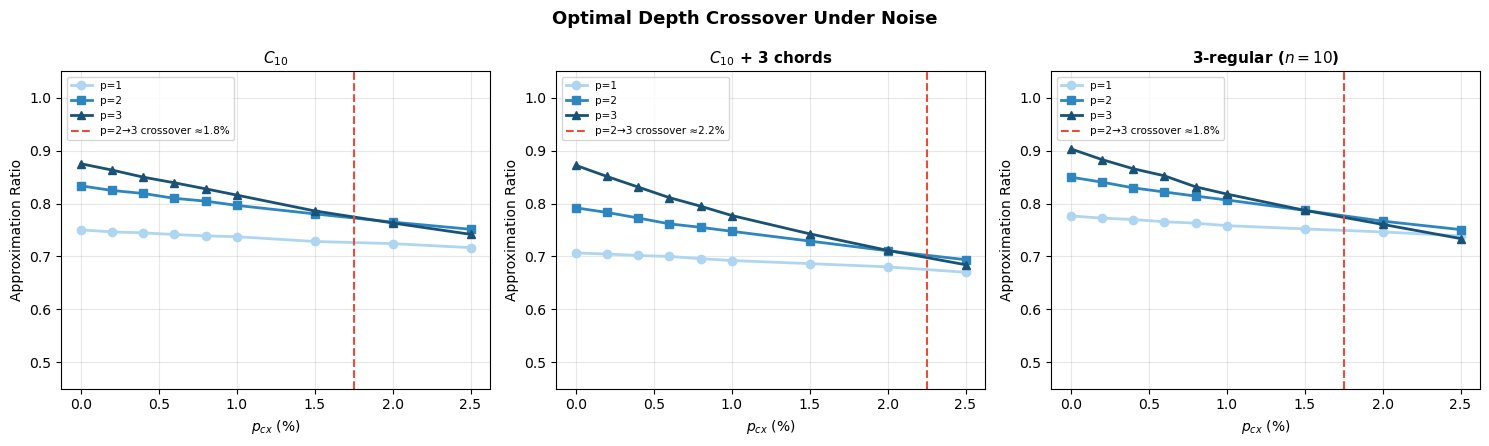

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, edges, opt), gkey in zip(axes, GRAPHS, GRAPH_KEYS):
    r1 = np.array(noise_results[gkey][1])
    r2 = np.array(noise_results[gkey][2])
    r3 = np.array(noise_results[gkey][3])

    ax.plot(pcx_pct, r1, 'o-', color='#AED6F1', lw=2, ms=6, label='p=1')
    ax.plot(pcx_pct, r2, 's-', color='#2E86C1', lw=2, ms=6, label='p=2')
    ax.plot(pcx_pct, r3, '^-', color='#1A5276', lw=2, ms=6, label='p=3')

    for (r_shallow, r_deep, label, color) in [
        (r2, r3, 'p=2→3', '#E74C3C'),
        (r1, r2, 'p=1→2', '#F39C12'),
    ]:
        cross = None
        for i in range(len(PCX_VALS)-1):
            if r_deep[i] >= r_shallow[i] and r_deep[i+1] < r_shallow[i+1]:
                cross = (PCX_VALS[i]*100 + PCX_VALS[i+1]*100) / 2
                break
        if cross:
            ax.axvline(cross, color=color, ls='--', lw=1.5,
                       label=f'{label} crossover ≈{cross:.1f}%')

    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel(r'$p_{cx}$ (%)', fontsize=10)
    ax.set_ylabel('Approximation Ratio', fontsize=10)
    ax.set_ylim(0.45, 1.05); ax.legend(fontsize=7.5)
    ax.grid(alpha=0.3)

plt.suptitle('Optimal Depth Crossover Under Noise', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 6. Landscape Flattening

Noise reduces the landscape variance $\Delta = \mathrm{std}_{(\gamma,\beta)}[F_1^{\text{noisy}}]$.
When $\Delta \to 0$, gradients vanish and optimizers fail — this is **noise-induced barren plateau** (Wang et al. 2021).

Landscape std vs noise level (C10, p=1):
  p_cx=0.000: std=0.1108  (drop=0.0%)
  p_cx=0.005: std=0.1078  (drop=2.7%)
  p_cx=0.010: std=0.1049  (drop=5.3%)
  p_cx=0.020: std=0.0987  (drop=10.9%)


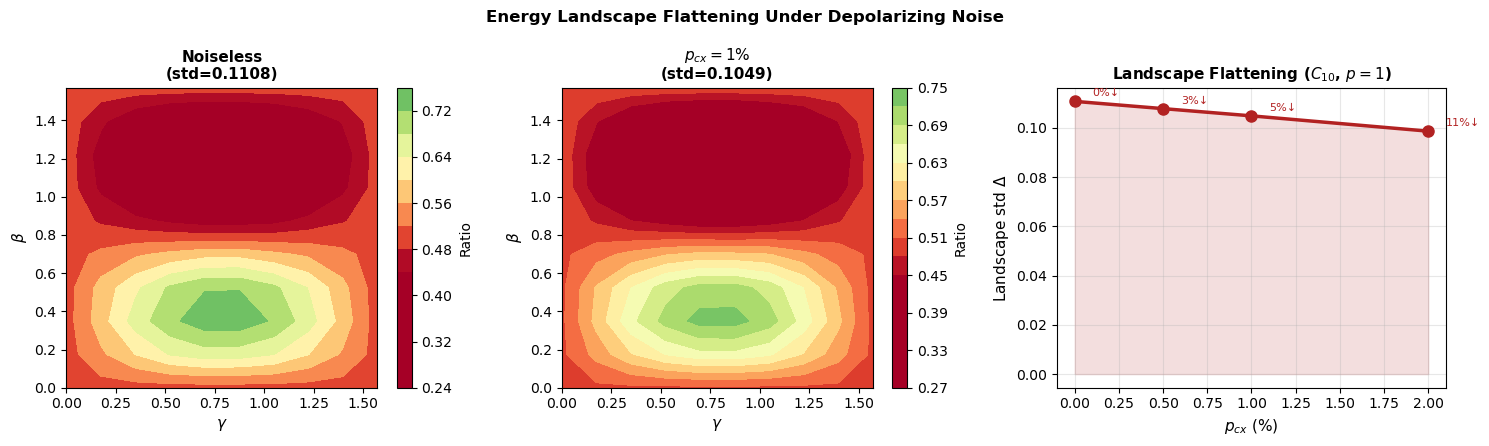

In [6]:
Ng = 10
gs = np.linspace(0, np.pi/2, Ng)
bs = np.linspace(0, np.pi/2, Ng)
PCX_FLAT = [0.000, 0.005, 0.010, 0.020]

flat_stds = []
print('Landscape std vs noise level (C10, p=1):')
for p_cx in PCX_FLAT:
    energies = []
    for g in gs:
        for b in bs:
            r = eval_noisy(e1, n, 1, [g], [b], p_cx, shots=2048)
            energies.append(r / 10)
    flat_stds.append(np.std(energies))
    print(f'  p_cx={p_cx:.3f}: std={flat_stds[-1]:.4f}  '
          f'(drop={100*(1-flat_stds[-1]/flat_stds[0]):.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (p_cx, title) in zip(axes[:2],
        [(0.0,'Noiseless'), (0.01,r'$p_{cx}=1\%$')]):
    Z = np.zeros((Ng, Ng))
    for i,g in enumerate(gs):
        for j,b in enumerate(bs):
            Z[j,i] = eval_noisy(e1, n, 1, [g], [b], p_cx, shots=2048) / 10
    cf = ax.contourf(gs, bs, Z, levels=15, cmap='RdYlGn', vmin=0.45, vmax=0.82)
    plt.colorbar(cf, ax=ax, label='Ratio')
    ax.set_xlabel(r'$\gamma$', fontsize=11); ax.set_ylabel(r'$\beta$', fontsize=11)
    ax.set_title(f'{title}\n(std={np.std(Z):.4f})', fontsize=11, fontweight='bold')

ax3 = axes[2]
ax3.plot([v*100 for v in PCX_FLAT], flat_stds, 'o-',
         color='firebrick', lw=2.5, ms=8)
ax3.fill_between([v*100 for v in PCX_FLAT], flat_stds, alpha=0.15, color='firebrick')
for pcx, std in zip(PCX_FLAT, flat_stds):
    ax3.annotate(f'{100*(1-std/flat_stds[0]):.0f}%↓',
                 xy=(pcx*100, std), xytext=(pcx*100+0.1, std+0.002),
                 fontsize=8, color='firebrick')
ax3.set_xlabel(r'$p_{cx}$ (%)', fontsize=11)
ax3.set_ylabel(r'Landscape std $\Delta$', fontsize=11)
ax3.set_title(r'Landscape Flattening ($C_{10}$, $p=1$)', fontsize=11, fontweight='bold')
ax3.grid(alpha=0.3)

plt.suptitle('Energy Landscape Flattening Under Depolarizing Noise', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 7. Summary

### Key Findings

**Ratio degradation is monotone in $p_{cx}$** and faster for deeper circuits.
At depth $p$, total CX $= 2p|E|$, so fidelity decays as $(1-p_{cx})^{2p|E|}$.
This makes $p=3$ degrade $3\times$ faster than $p=1$.

**Crossover points** (where shallower circuit first outperforms deeper one):
determined from the sweep above. Translating thresholds to real hardware
requires detailed noise characterisation beyond this simple depolarizing model.

**Landscape flattening** quantifies optimizer difficulty:
even at $p_{cx}=1\%$, landscape variance drops measurably,
explaining why gradient-free optimizers are preferred over gradient-based methods on noisy hardware.

### Hardware Implications

| $p_{cx}$ | Optimal depth | Status |
|-----------|--------------|--------|
| $< 0.5\%$ | $p=2$ or $p=3$ | IBM/Google best today |
| $0.5\text{--}1\%$ | $p=2$ | NISQ near-term |
| $> 1.5\%$ | $p=1$ | Early NISQ |
| $\to 0$ | Large $p$ | Fault-tolerant era |

### Limitation: Fixed vs Noise-Aware Parameters

This notebook uses **noiseless optimal parameters** (from Notebook 05) to isolate the effect of noise on circuit fidelity.
A complementary approach — re-optimising $(\boldsymbol{\gamma}, \boldsymbol{\beta})$ directly under noise — typically recovers 2–5% additional ratio at moderate noise levels, at the cost of running the full optimisation loop on noisy hardware.
This is left as future work.

---
## References

- Farhi, Goldstone, Gutmann. arXiv:1411.4028 (2014).
- Wang et al. *Nature Commun.* 12, 6961 (2021).
- Cerezo et al. *Nature Reviews Physics* 3, 625 (2021).